In [1]:
import argparse
import pathlib
from pathlib import Path
import time
from datetime import timedelta
import json
import os
import pandas as pd
import numpy as np
import itertools
import csv
import anndata
import javabridge
import tensorflow as tf
import pathml
from pathml.core import CODEXSlide
from pathml.core import SlideData
from scipy.spatial.distance import cdist
from pathml.preprocessing import Pipeline, CollapseRunsCODEX, SegmentMIF, QuantifyMIF

2023-02-24 02:02:01.248606: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-02-24 02:02:01.248660: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
print(f"working dir: {os.getcwd()}")

working dir: /n/data2/dfci/cancerimm/wucherpfennig/bhawesh


In [3]:
# Data Directory

os.chdir("/n/data2/dfci/cancerimm/wucherpfennig/bhawesh/projects/CODEX/test_p02")

In [4]:
metadata_p = Path("experiment_edited.json")

In [5]:
! ls

experiment_edited.json
p02_bl_cropped_20220516_Exp030_P02_BL_anndata.h5ad
p02_bl_cropped_20220516_Exp030_P02_BL_anndata.h5seurat
p02_bl_cropped_20220516_Exp030_P02_BL.h5path
p02_bl_cropped_20220516_Exp030_P02_BL_h5path_channel_order.txt
stitched.pattern
symlink
symlink_edited


In [6]:
with open(metadata_p) as f:
            experiment_metadata = json.load(f)
            channel_names = experiment_metadata["channelNames"]["channelNamesArray"]
            experiment_name = experiment_metadata["name"]

In [7]:
newlist = []
for i, v in enumerate(channel_names):
    totalcount = channel_names.count(v)
    count = channel_names[:i].count(v)
    newlist.append(v + "-" + str(count + 1) if totalcount > 1 else v)
channel_names = newlist

In [8]:
wsi_path = 'p02_bl_cropped_20220516_Exp030_P02_BL.h5path'
channels_path =  'p02_bl_cropped_20220516_Exp030_P02_BL_h5path_channel_order.txt'

In [9]:
wsi = SlideData(str(wsi_path))

/n/data2/dfci/cancerimm/wucherpfennig/tools/conda_codex_lab/lib/python3.8/site-packages/anndata/_io/h5ad.py:64: FutureWarning: The `force_dense` argument is deprecated. Use `as_dense` instead.
  warn(


In [10]:
channels = pd.read_csv(channels_path, sep = "\t", header = None)
channel_names = list(channels[1].values)

print("loaded channels:", channel_names, "\n")

loaded channels: ['Blank-1', 'Blank-2', 'Blank-3', 'Clec2d', 'PD-L1', 'CD45-RO', 'N-Cadherin', 'TCF7', 'CD3e', 'CD163', 'CD103', 'CXCR5', 'FAP', 'E-Cadherin', 'cl-Caspase3', 'PD-1', 'GZMB-D6E9W', 'CD1c', 'DAPI-09', 'CXCL13', 'CA9', 'FOXP3', 'CD56', 'CD31', 'GZMK', 'SLUG', 'Podoplanin', 'CD66b', 'Ki67', 'CD4', 'MHC1', 'CD25', 'DC-LAMP', 'Pancytokeratin', 'CD8', 'CD68', 'CD20', 'HLA-DR', 'Vimentin', 'Blank-4', 'Blank-5', 'Blank-6'] 



In [11]:
# 'CD3e', 'CD4', 'CD8', 'CD68', 'CD20', 'CD31', 'Pancytokeratin'

In [12]:
wsi.tiles.keys

['(0, 0)',
 '(0, 1848)',
 '(0, 3696)',
 '(1848, 0)',
 '(1848, 1848)',
 '(1848, 3696)',
 '(3696, 0)',
 '(3696, 1848)',
 '(3696, 3696)']

In [13]:
tile = wsi.tiles[(1848, 1848)]
tile.masks.keys()

dict_keys(['cell_segmentation', 'nuclear_segmentation'])

In [14]:
mask = tile.masks["nuclear_segmentation"].astype(int).squeeze()

In [15]:
mask.shape, len(np.unique(mask))

((2048, 2048), 2383)

In [16]:
# Convert to float and remove nans due to overflow by the max of the array
# If na
tile.image = tile.image.astype(np.float64)
global_max = np.nanmax(tile.image[tile.image != np.inf])
print(global_max)
tile.image[tile.image>global_max] = global_max

65504.0


In [17]:
# Raise assertion error if there are nans in the image
assert not np.isnan(tile.image).any(), "There are NaN values in the array"
assert not np.isinf(tile.image).any(), "Array contains infinite value(s)."

In [18]:
os.chdir("/n/data2/dfci/cancerimm/wucherpfennig/bhawesh/code")

In [19]:
from transforms import REDSEAQuantifyMIF

In [20]:
import matplotlib.pyplot as plt

In [21]:
redsea = REDSEAQuantifyMIF(segmentation_mask=None, element_shape="diamond",
                           element_size = 4,
                growth = 3, method = 'Standard', num_neighbors = 30,
                           use_actual_overlap_for_reinforcement = False, alpha = 1)

# https://www.frontiersin.org/articles/10.3389/fimmu.2021.652631/full
# use_actual_overlap_for_reinforcement = False means that we will be approximating equation 4 in above paper
# with equation 5, where they assume that the overlap in boundary with adjacent cells is approximately equal
# to the whole boundary. Here alpha is 1 as well. So we use all signals on boundary to reinforce. This can 
# cause a lot of signal gain in some cells. So, a way to reduce that is to use smaller alpha. This is not
# a very rigorous way though. But if we use use_actual_overlap_for_reinforcement = True and alpha = 1 (the
# right way to only reinforce signals from boundary of cells which overlap with adjacent cells), the spillover
# correction is very small on most cell in my limited validation. Please experiment with this to know what
# would be the best parameter combinations for (use_actual_overlap_for_reinforcement, alpha).

In [22]:
# segmentation_zero_boundary = redsea.get_segmentation_zero_boundary(mask.copy())
        
assert not np.isinf(tile.image).any(), "There are np.inf values in the array. If this is\
is due to numeric overflow, you can fix it by removing np.inf by max of the array (max excluding inf.)"
assert not np.isnan(tile.image).any(), "Array contains NaN value(s)."



In [23]:
mask_reindexed, mask_counts = REDSEAQuantifyMIF.split_cells(mask.copy())

In [24]:

mask_dilated = REDSEAQuantifyMIF.grow_masks(mask_reindexed, redsea.growth, redsea.method, redsea.num_neighbors)


Standard growth selected


In [25]:
%%time
counts_redsea, counts_uncomp = redsea.compute_redsea_counts_matrix(img=tile.image, mask=mask_dilated)

CPU times: user 16min 25s, sys: 1.39 s, total: 16min 26s
Wall time: 16min 28s


In [26]:
counts_uncomp

array([[176.65116279,  97.68217054,  46.73643411, ..., 181.41085271,
        166.05426357,  91.71317829],
       [181.04424779,  98.36283186,  45.02876106, ..., 189.90707965,
        172.11504425,  96.20132743],
       [188.26327434, 101.91814159,  45.24557522, ..., 200.16150442,
        170.93362832,  93.19690265],
       ...,
       [160.51893939,  96.96969697,  44.85227273, ..., 191.14393939,
        171.28787879,  95.81818182],
       [160.29378531,  93.5819209 ,  46.19774011, ..., 170.60451977,
        161.40112994,  92.42937853],
       [154.88095238, 100.73809524,  48.86904762, ..., 164.10714286,
        163.71428571,  92.3452381 ]])

In [27]:
counts_redsea

array([[261.20265326, 144.27035726,  69.79861158, ..., 267.48140097,
        247.2823737 , 135.56091919],
       [239.65434538, 131.13685853,  59.93926416, ..., 248.22833089,
        228.03025182, 126.85819008],
       [222.70932431, 121.25187259,  53.84726213, ..., 235.89116306,
        203.04676526, 110.28156096],
       ...,
       [217.40699222, 131.34572072,  59.62039312, ..., 257.06275594,
        230.89900696, 128.39235258],
       [190.66639883, 112.23457627,  54.89726721, ..., 204.01760201,
        193.21358443, 110.65353421],
       [214.7556391 , 140.09767474,  67.06725146, ..., 228.47925369,
        224.65441381, 126.76691729]])

In [28]:
def get_closest_median(arr):
    median = np.median(arr)
    closest = arr[np.abs(arr - median).argmin()]
    return closest

In [29]:
counts_redsea.shape

(2706, 42)

In [30]:
CD_20_comp_3_redsea = counts_redsea[:, channel_names.index('CD20')]

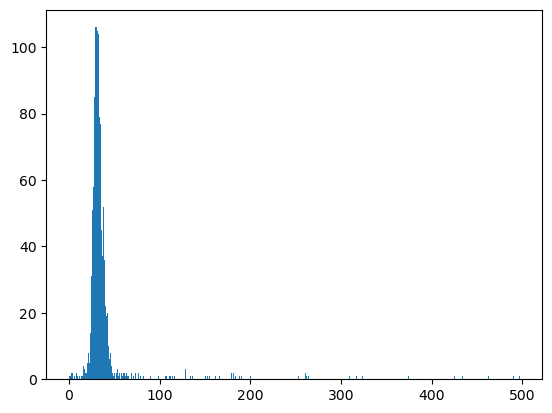

In [31]:
p = plt.hist(CD_20_comp_3_redsea[CD_20_comp_3_redsea<500], bins=1000)
plt.show()

In [32]:
CD_20_uncomp_3_redsea = counts_uncomp[:, channel_names.index('CD20')]

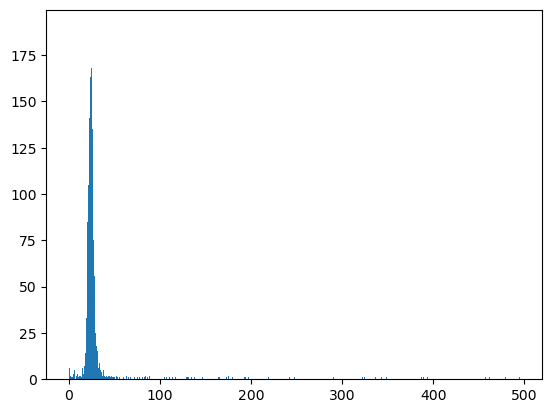

In [33]:
p = plt.hist(CD_20_uncomp_3_redsea[CD_20_uncomp_3_redsea<500], bins=1000)


In [34]:
from scipy.stats import percentileofscore

In [35]:
percentileofscore(CD_20_uncomp_3_redsea, 1000)

98.92830746489282

In [36]:
cutoff_CD_20 = np.percentile(CD_20_uncomp_3_redsea, 94)

In [37]:
cutoff_CD_20

63.094687943262386

In [38]:
CD_20_pos_cells_comp_r = CD_20_comp_3_redsea>50
CD_20_pos_cells_uncomp_r = CD_20_uncomp_3_redsea>50

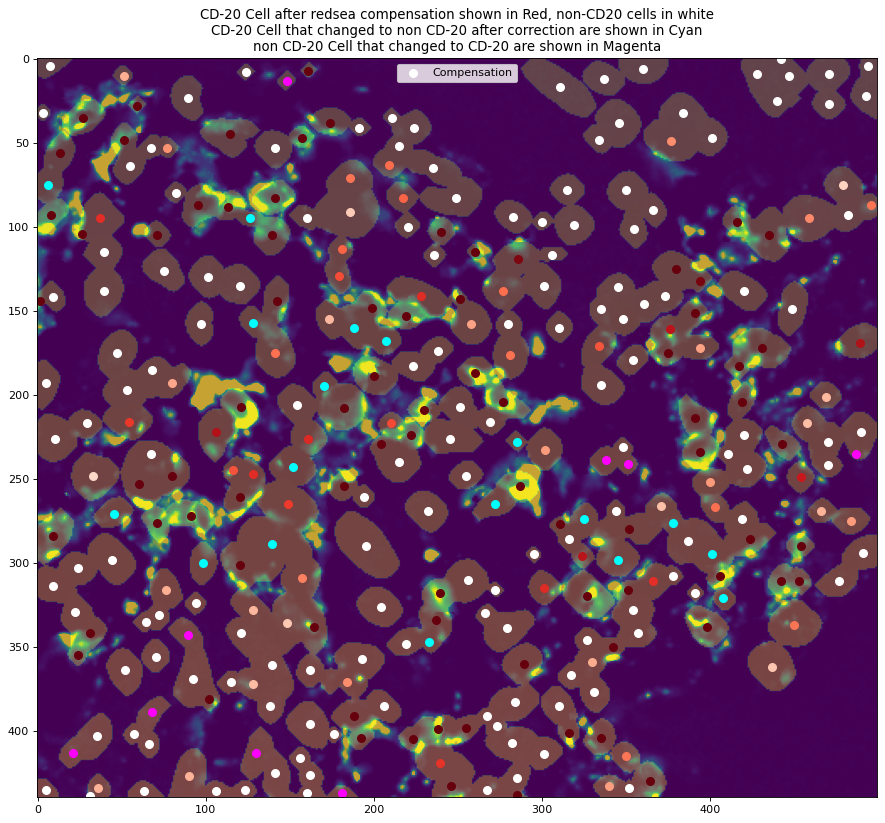

In [39]:
from matplotlib.pyplot import figure
idx1, idx2, idx3, idx4 = 1600, 2040, 0, 500
figure(figsize=(16, 12), dpi=80)
CD_pos_neg_r = 0
CD_neg_pos_r = 0
CD_pos_r = 0
CD_neg_r = 0
for label in np.unique(mask_dilated[idx1:idx2, idx3:idx4]):
    if label!=0:
        rows, columns = np.where(mask_dilated[idx1:idx2, idx3:idx4] ==label)
        r_, c_ =  get_closest_median(rows), get_closest_median(columns)
        is_CD_20 = CD_20_pos_cells_comp_r[label-1]
        was_CD_20 = CD_20_pos_cells_uncomp_r[label-1]
        value = CD_20_uncomp_3_redsea[label-1]
        comp_value = CD_20_comp_3_redsea[label-1]
        
        if was_CD_20 and not is_CD_20:
            plt.scatter(c_,r_, color='cyan', s = 50, )
            CD_pos_neg_r+=1
            CD_neg_r+=1
        
        elif not was_CD_20 and not is_CD_20:
            plt.scatter(c_,r_, color='white', s = 50,)
            CD_neg_r+=1
        
        elif not was_CD_20 and is_CD_20:
            plt.scatter(c_,r_, color='magenta', s = 50,)
            CD_neg_pos_r+=1
            CD_pos_r+=1
        else:
            plt.scatter(c_,r_, c= comp_value, vmin = 0, vmax =np.percentile(CD_20_comp_3_redsea, 97),
                          s = 50, cmap='Reds', )
            CD_pos_r+=1
plt.imshow(tile.image[idx1:idx2, idx3:idx4, channel_names.index('CD20')], vmax=3000)
plt.imshow(mask_dilated[idx1:idx2, idx3:idx4],alpha=0.3)

plt.title("CD-20 Cell after redsea compensation shown in Red, non-CD20 cells in white\n" + 
                "CD-20 Cell that changed to non CD-20 after correction are shown in Cyan\n"+
         "non CD-20 Cell that changed to CD-20 are shown in Magenta")
plt.legend(['Compensation'], markerscale=1, loc = "upper center")

plt.show()

In [40]:
CD_pos_neg_r, CD_neg_pos_r, CD_pos_r, CD_neg_r

(18, 9, 147, 163)

In [41]:
# More cells turn to Pos from Neg due to reinforcement on borders. If there is more signal on border,
# than from neighboring cells, the cells will gain signals
# Can control by only applying a fraction of signal on borders.
# Amount of correction depends on how big is the "border" controlled by structring element size. Higher
# size of structuring elements lead to more correction. 

In [42]:
# 'CD3e', 'CD4', 'CD8', 'CD68', 'CD20', 'CD31', 'Pancytokeratin'

In [43]:
idx = [channel_names.index('CD3e'), channel_names.index('CD4'), channel_names.index('CD8'), 
       channel_names.index('CD68'), channel_names.index('CD20'), channel_names.index('CD31'),
       channel_names.index('Pancytokeratin')]

In [44]:
import numpy as np

def standardize_and_clip(array, a_min=None, a_max=None):
    # Calculate mean and standard deviation along the channels (axis=2)
    mean = np.mean(array, axis=0)
    std = np.std(array, axis=0)
    
    # Standardize the array along each channel
    standardized = (array - mean) / std
    
    # Clip the standardized array to the specified range
    if a_min is not None and a_max is not None:
        clipped = np.clip(standardized, a_min, a_max)
    
        return clipped
    else:
        return standardized


In [45]:
counts_redsea_umap = counts_redsea[:, idx]

In [46]:
counts_umap_uncomp = counts_uncomp[:, idx]

In [47]:
counts_redsea_umap - np.mean(counts_redsea_umap, axis=0)

array([[ 874.47088441, 1005.95189561, -104.87579247, ...,  -39.70346867,
         -65.17381363, -363.27640638],
       [-143.35384116,  -81.43512779,   40.83517899, ...,  -43.74753977,
         -54.33571127, -386.0861268 ],
       [ 190.91267987,  284.37068539, -103.387973  , ...,  -43.63050377,
         -72.44949858, -333.45660141],
       ...,
       [ -76.0652114 ,  -88.67716613,  -93.82035635, ...,    4.83209356,
         217.86069342, -379.0670826 ],
       [ 544.31866009,  445.33649184,  616.82177606, ...,  455.16277812,
         -70.46540006, -423.47503616],
       [ 113.1476063 ,  -19.74935687,   -5.76990275, ...,  -37.62220716,
         -59.12483111, -210.12414479]])

In [48]:
counts_redsea_umap_std = standardize_and_clip(counts_redsea_umap, a_max=6, a_min=-6)

In [49]:
counts_umap_uncomp_std = standardize_and_clip(counts_umap_uncomp, a_max = 6, a_min = -6)

In [50]:
import numpy as np
import umap

In [51]:


def create_umap_embeddings(array, n_neighbors=15, min_dist=0.1):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist)
    embeddings = reducer.fit_transform(array)
    return embeddings
def plot_umap_embeddings(embeddings, s=5):
    
    plt.scatter(embeddings[:, 0], embeddings[:, 1], s=s)
    plt.show()

In [52]:
embeddings_redsea = (create_umap_embeddings(counts_redsea_umap_std, n_neighbors=15))

In [53]:
embeddings_uncomp = (create_umap_embeddings(counts_umap_uncomp_std, n_neighbors=15))

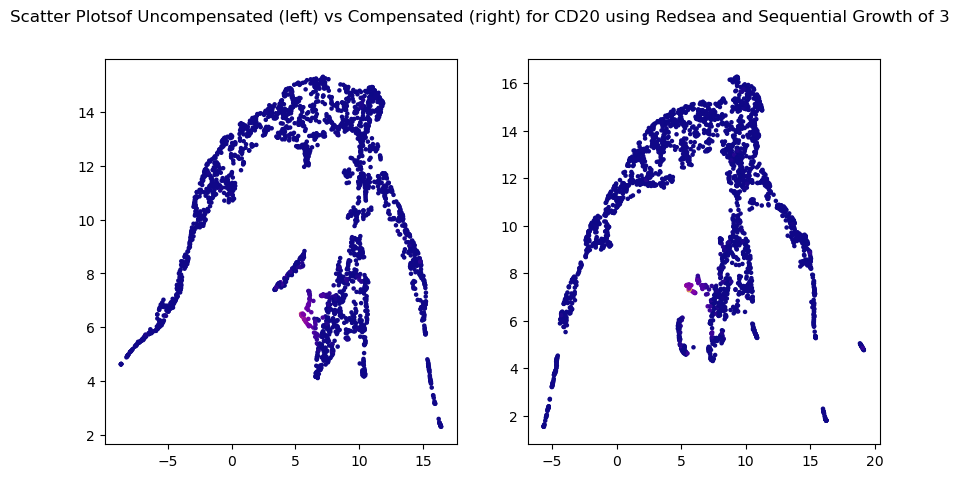

In [54]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(embeddings_uncomp[:, 0], embeddings_uncomp[:, 1],
               s=5, c=counts_umap_uncomp[:, 4], cmap='plasma')
axs[1].scatter(embeddings_redsea[:, 0], embeddings_redsea[:, 1], s=5, 
                           c=counts_redsea_umap[:, 4], cmap='plasma')
fig.suptitle('Scatter Plotsof Uncompensated (left) vs Compensated (right) for CD20 using Redsea and \
Sequential Growth of 3')
plt.show()